In [1]:
from utils import plot_bidirectional_heatmaps, get_matrices, load_results

In [2]:
DESIRED_ORDER = ["PET-MAD", "BESPOKE", "FF", "HF", "FTL", "HTL"]

MODEL_MAPPING = {
    "pet-mad": "PET-MAD",
    "bespoke": "BESPOKE",
    "ff": "FF",
    "hf": "HF",
    "ftl": "FTL",
    "htl": "HTL"
}


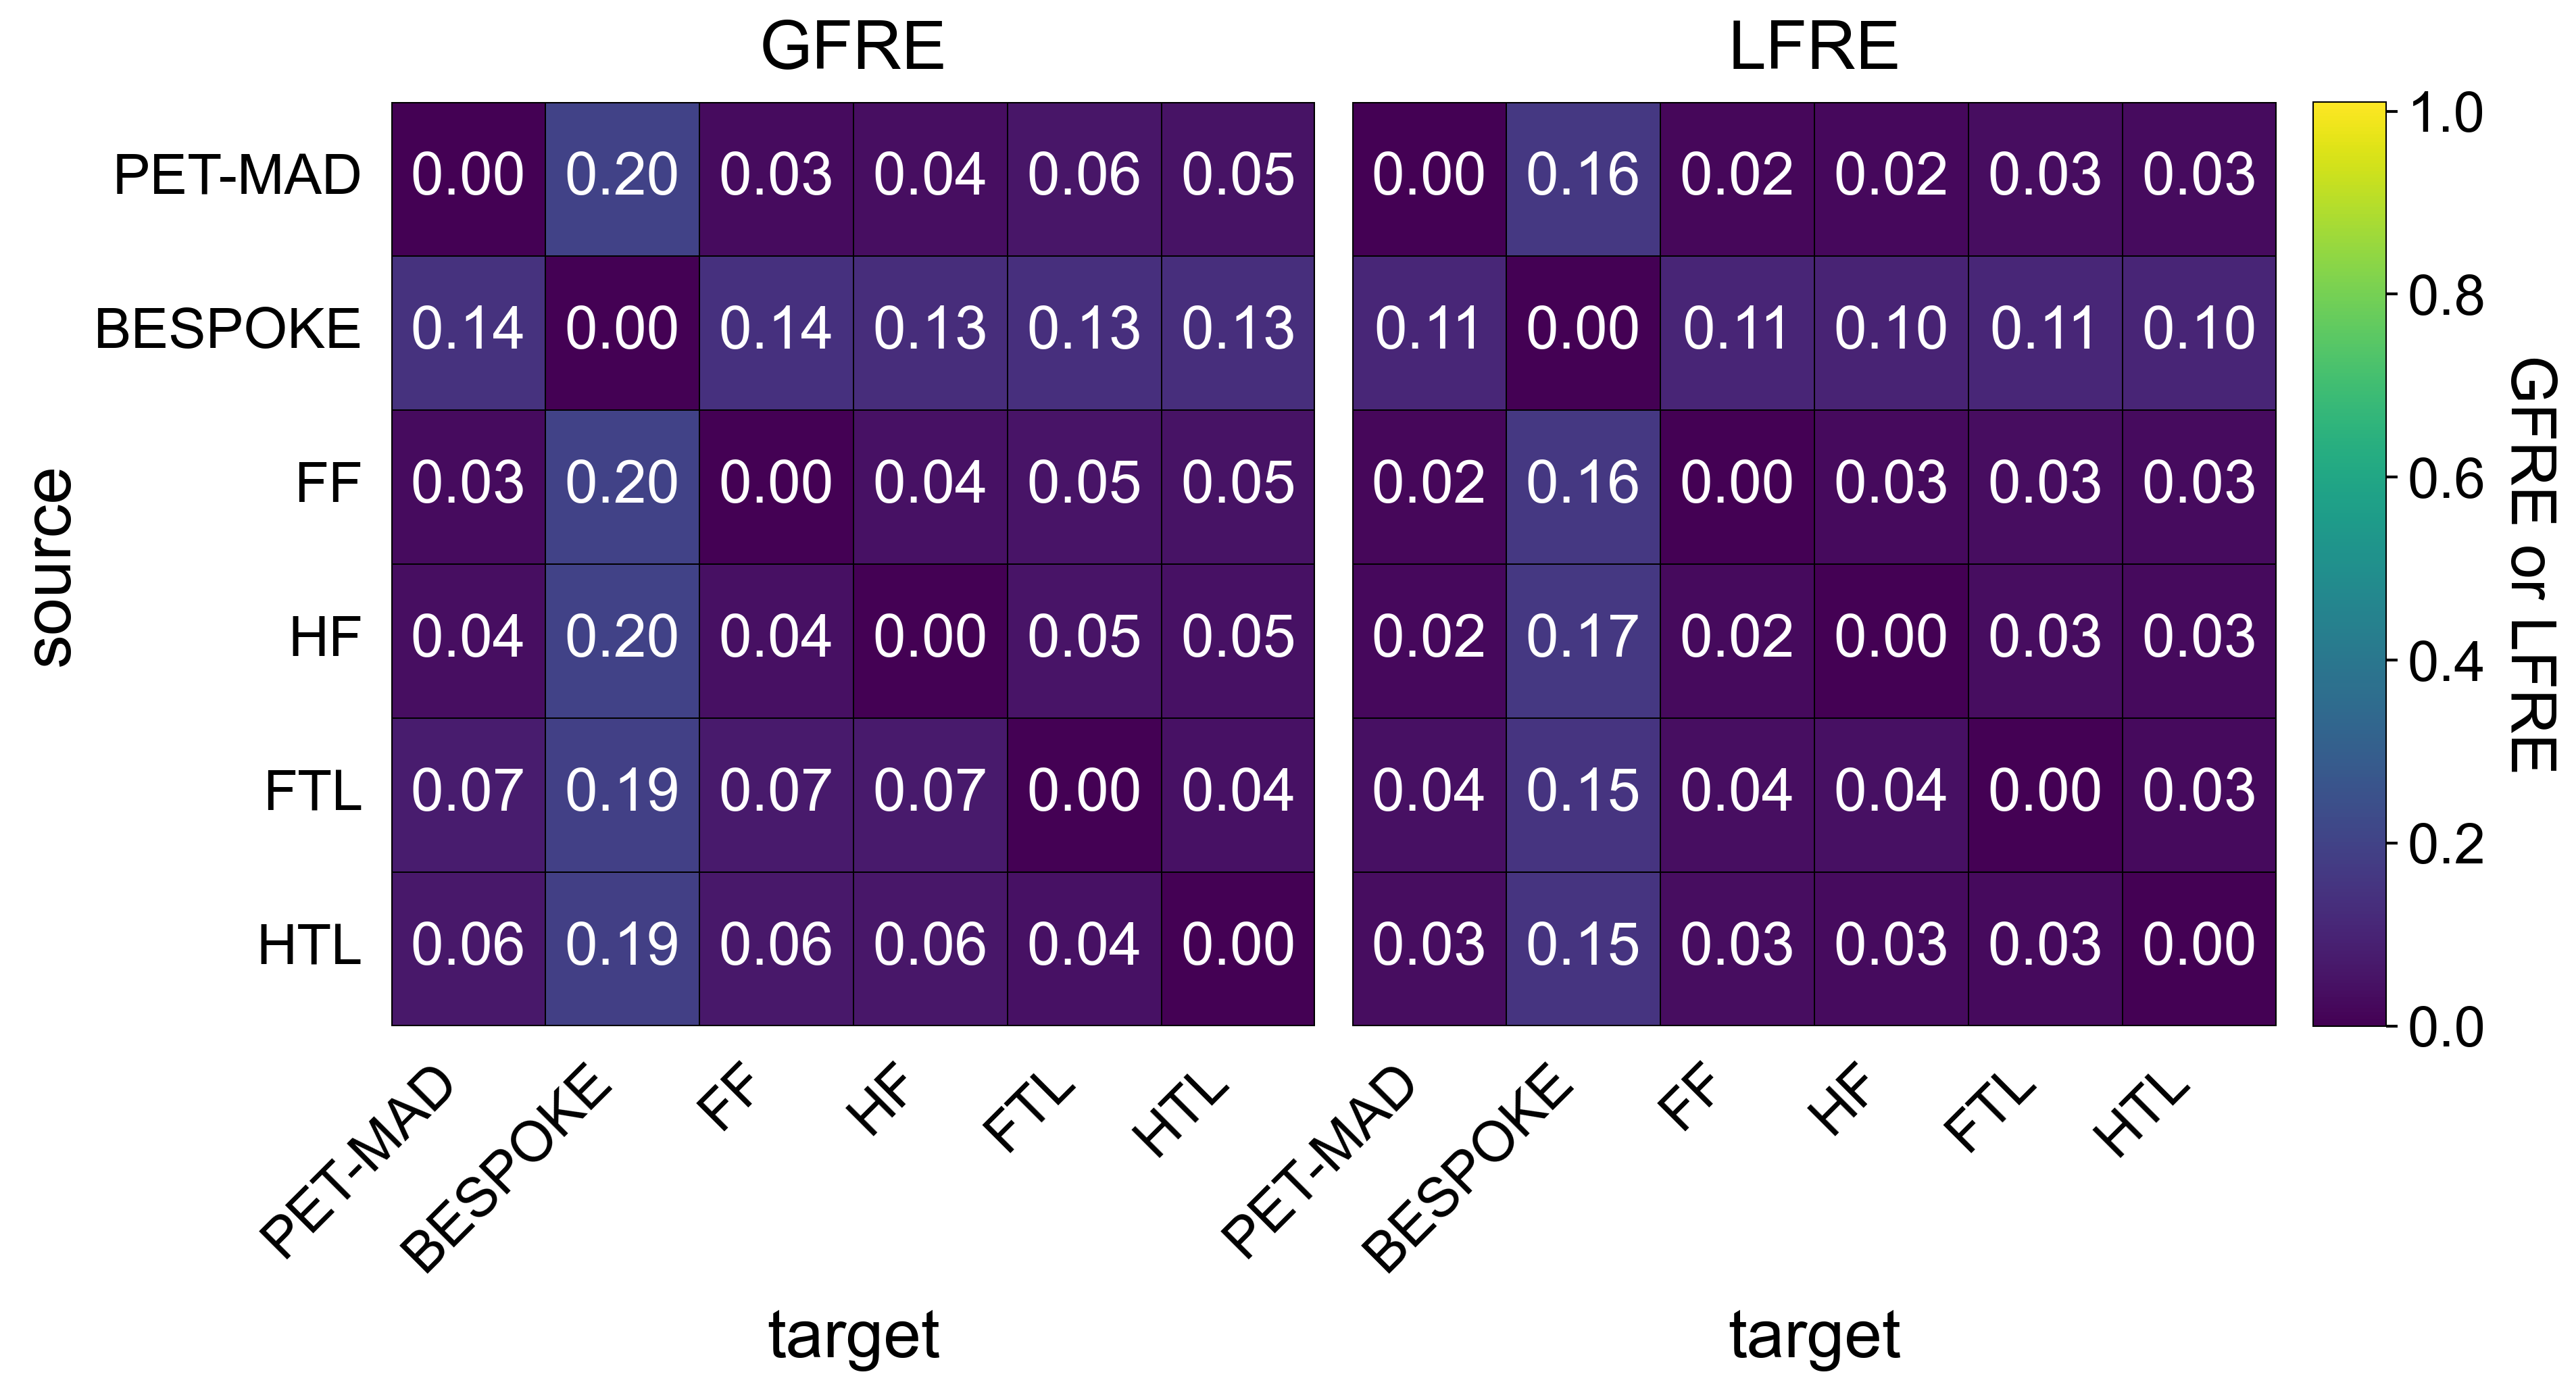

In [4]:
import os

base = "../results/reconstruction_errors/fine-tuning"

results_gfre = load_results(os.path.join(base, "gfre_model_vs_model.json"))
results_lfre = load_results(os.path.join(base, "lfre_model_vs_model.json"))

error_matrix_gfre, annot_matrix_gfre = get_matrices(results_gfre, DESIRED_ORDER, MODEL_MAPPING)
error_matrix_lfre, annot_matrix_lfre = get_matrices(results_lfre, DESIRED_ORDER, MODEL_MAPPING)

plot_bidirectional_heatmaps(
    error_matrix_gfre, annot_matrix_gfre,
    error_matrix_lfre, annot_matrix_lfre,
    title1="GFRE",
    title2="LFRE",
    cbar_label="GFRE or LFRE",
    save_path="../results/figures/fine-tuning/model_vs_model.pdf",
)

In [6]:
import os

CHECKPOINTS = ["bespoke", "ff", "hf", "ftl", "htl"]
DESIRED_ORDER = ["BESPOKE", "FF", "HF", "FTL", "HTL"]

MODEL_MAPPING = {
    "pet-mad": "PET-MAD",
    "bespoke": "BESPOKE",
    "ff": "FF",
    "hf": "HF",
    "ftl": "FTL",
    "htl": "HTL"
}

base = "../results/reconstruction_errors/fine-tuning/progress"

results = []

for checkpoint_type in CHECKPOINTS:
    results_gfre = load_results(os.path.join(base, checkpoint_type, f"gfre_{checkpoint_type}.json"))
    results_lfre = load_results(os.path.join(base, checkpoint_type, f"lfre_{checkpoint_type}.json"))

    gfre = results_gfre.get(checkpoint_type)
    lfre = results_lfre.get(checkpoint_type)
    results.append((checkpoint_type, gfre, lfre))

In [7]:
import pandas as pd


data_records = []
for checkpoint_type, gfre_dict, lfre_dict in results:
    display_name = MODEL_MAPPING[checkpoint_type]

    for epoch_key, error_values in gfre_dict.items():
        epoch = int(epoch_key.split('_')[-1])
        data_records.append({
            'Model': display_name,
            'Epoch': epoch,
            'Error Type': 'GFRE',
            'Error Value': error_values['A_to_B']
        })

    for epoch_key, error_values in lfre_dict.items():
        epoch = int(epoch_key.split('_')[-1])
        data_records.append({
            'Model': display_name,
            'Epoch': epoch,
            'Error Type': 'LFRE',
            'Error Value': error_values['A_to_B'] 
        })

df = pd.DataFrame(data_records)
df['Model'] = pd.Categorical(df['Model'], categories=DESIRED_ORDER, ordered=True)
df = df.sort_values(['Error Type', 'Model', 'Epoch'])


In [8]:
import matplotlib.pyplot as plt
from matplotlib import rcParams


rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 20,
    'axes.titlesize': 28,
    'axes.labelsize': 28,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 23,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.bottom': True,
    'axes.spines.left': True,
    'axes.edgecolor': 'black',
    'axes.linewidth': 2.0,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.5,
    'ytick.major.width': 2.5,
    'xtick.minor.width': 2.0,
    'ytick.minor.width': 2.0,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'lines.linewidth': 4,
    'patch.edgecolor': 'black',
    'patch.linewidth': 0.8,
})


def get_plot(df, save_path=None):
    fig, ax = plt.subplots(figsize=(14, 10))

    colors = [
        "#FF00FF", 
        "black",
        "#0033FF", 
        "#02b802",
        "red",
    ]

    error_types = ['GFRE', 'LFRE']

    legend_model_handles = []
    legend_model_labels = []

    legend_style_handles = [
        plt.Line2D([0], [0], color="grey", linestyle='-', linewidth=5),
        plt.Line2D([0], [0], color="grey", linestyle='--',linewidth=5),
    ]
    legend_style_labels = ['GFRE', 'LFRE']

    for i, model in enumerate(DESIRED_ORDER):
        color = colors[i % len(colors)]
        model_has_data = False
        for error_type in error_types:
            model_data = df[(df['Model'] == model) & (df['Error Type'] == error_type)]
            if len(model_data) == 0:
                continue

            linestyle = '-' if error_type == 'GFRE' else '--'
            ax.plot(
                model_data['Epoch'],
                model_data['Error Value'],
                linestyle=linestyle,
                color=color,
                linewidth=4,
                alpha=1,
                marker=''
            )
            model_has_data = True

        if model_has_data:
            legend_model_handles.append(
                plt.Line2D([0], [0], color=color, linestyle='-', linewidth=5)
            )
            legend_model_labels.append(model)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Reconstruction error', labelpad=12)
    ax.set_xscale("log")    

    ax.set_xlim(left=0, right=1350)
    ax.tick_params(axis='both', which='major', width=2.5, length=8)
    ax.tick_params(axis='both', which='minor', width=2.0, length=4)

    legend1 = ax.legend(
        legend_model_handles,
        legend_model_labels,
        loc='upper center',
        bbox_to_anchor=(0.25, -0.14),
        frameon=False,
        ncol=min(5, len(legend_model_labels)),
        title='Model',
        title_fontsize=26,
        handlelength=1.8,
        handletextpad=0.6,
        columnspacing=0.8,
    )
    ax.add_artist(legend1)

    legend2 = ax.legend(
        legend_style_handles,
        legend_style_labels,
        loc='upper center',
        bbox_to_anchor=(0.8,-0.14),
        frameon=False,
        ncol=2,
        title='Error type',
        title_fontsize=26,
        handlelength=1.8,
        handletextpad=0.4,
        columnspacing=0.8,
    )

    plt.tight_layout(rect=[0, 0.15, 1, 1])

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

/var/folders/k8/vgtm1rzd62967242ltpbhgnh0000gn/T/ipykernel_16071/2278615731.py:88: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(left=0, right=1350)


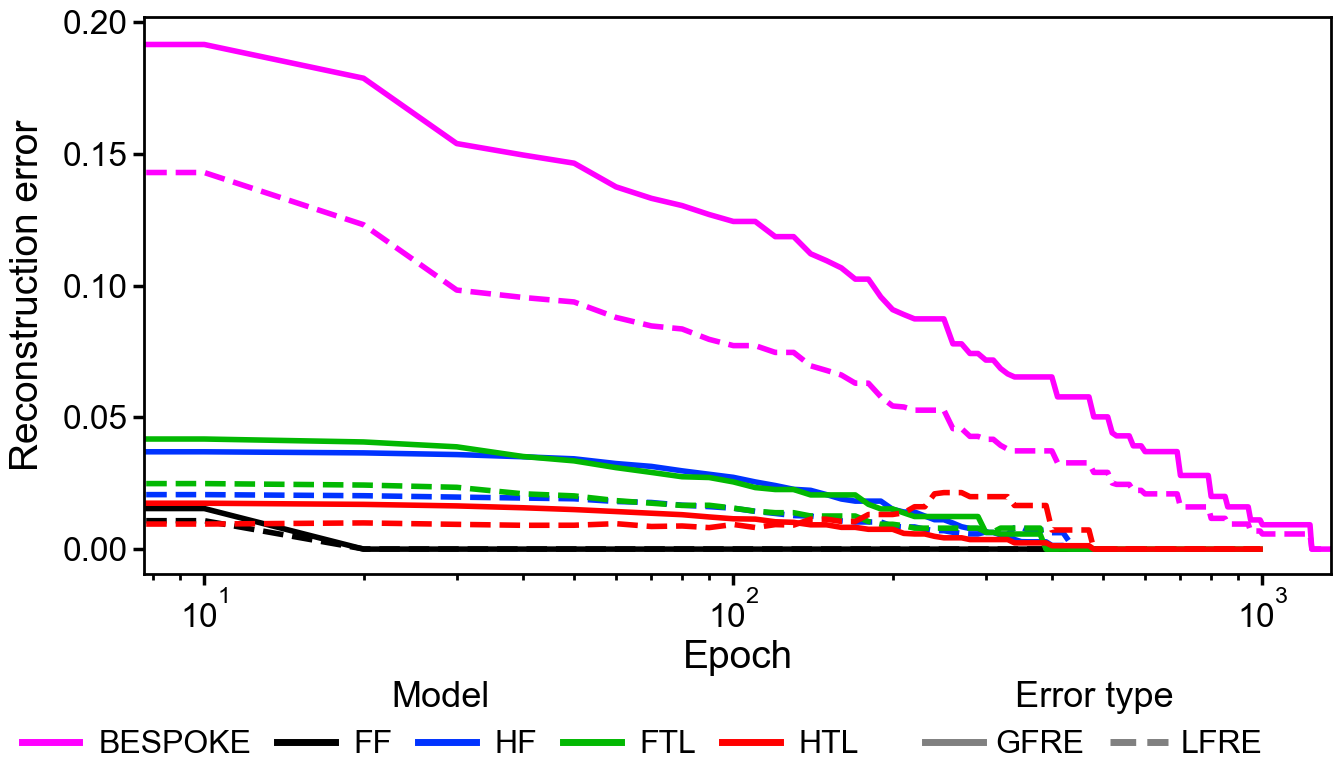

In [11]:
get_plot(df, "../results/figures/fine-tuning/progress.pdf",)